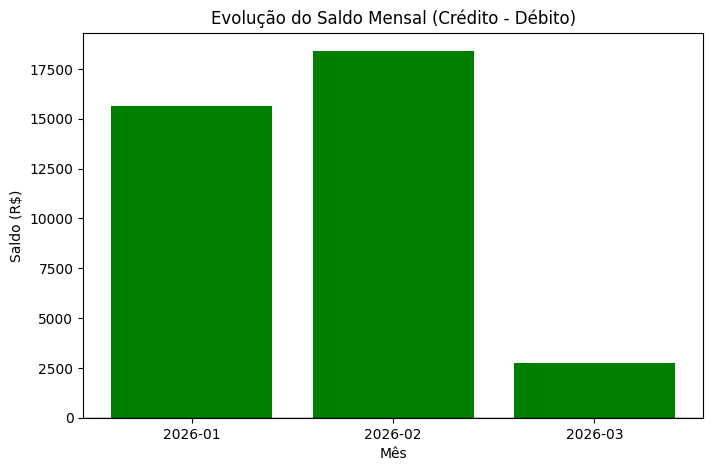

✅ Gráfico 'grafico.png' gerado e salvo com sucesso!


In [6]:
import matplotlib.pyplot as plt

if 'resumo_final' in locals() and resumo_final:
    meses = sorted(resumo_final.keys())
    saldos = [resumo_final[m]['saldo'] for m in meses]

    plt.figure(figsize=(8, 5))
    barras = plt.bar(meses, saldos, color=['green' if s > 0 else 'red' for s in saldos])
    
    plt.title('Evolução do Saldo Mensal (Crédito - Débito)')
    plt.xlabel('Mês')
    plt.ylabel('Saldo (R$)')
    plt.axhline(0, color='black', linewidth=1)
    
    plt.savefig('grafico.png')
    plt.show()
    print("✅ Gráfico 'grafico.png' gerado e salvo com sucesso!")

In [4]:
transacoes_validas, qtd_lidas, qtd_invalidas = ler_transacoes("transacoes.csv")

if transacoes_validas:
    resumo_final, transacoes_suspeitas, data_inicial, data_final = gerar_relatorio(transacoes_validas)
    
    exibir_relatorio(resumo_final, transacoes_suspeitas, data_inicial, data_final)
    
    salvar_json(resumo_final, len(transacoes_validas), qtd_invalidas)
    print("\n✅ Relatório exportado com sucesso para 'relatorio.json'!")

Total de linhas lidas: 20
Linhas válidas: 15
Linhas inválidas: 5

============================== RELATÓRIO MENSAL ==============================
Período analisado: 2026-01-05 a 2026-03-30 (84 dias)
Mês: 2026-01
  Transações:    5
  Total crédito: R$ 16.000,00
  Total débito:  R$ 380,50
  Saldo:         R$ 15.619,50
  Média:         R$ 3.276,10
  Maior valor:   R$ 12.500,00
  Menor valor:   R$ 50,00

Mês: 2026-02
  Transações:    5
  Total crédito: R$ 19.000,00
  Total débito:  R$ 600,00
  Saldo:         R$ 18.400,00
  Média:         R$ 3.920,00
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 80,00

Mês: 2026-03
  Transações:    5
  Total crédito: R$ 3.500,00
  Total débito:  R$ 729,90
  Saldo:         R$ 2.770,10
  Média:         R$ 845,98
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 60,00

============================== TRANSAÇÕES SUSPEITAS ==========================
ID: 3 | Cliente: CLI003 | Data: 2026-01-15 | Valor: R$ 12.500,00
ID: 7 | Cliente: CLI003 | Data: 2026-02-14 | Val

In [3]:
import csv
import json
from datetime import datetime

LIMITE_SUSPEITO = 10000.00

def validar_transacao(linha):
    """Valida e limpa os dados. Uso de try/except exigido para Float e Datetime."""
    try:
        if not linha.get('id', '').strip() or not linha.get('id').isdigit():
            return None
        
        if not linha.get('cliente_id', '').strip():
            return None
            
        if linha.get('tipo', '').strip().lower() not in ['credito', 'debito']:
            return None
            
        try:
            data_obj = datetime.strptime(linha['data'].strip(), "%Y-%m-%d")
        except ValueError:
            return None
            
        try:
            valor_float = float(linha['valor'])
            if valor_float <= 0:
                return None
        except ValueError:
            return None
            
        return {
            'id': int(linha['id']),
            'data': data_obj,
            'cliente_id': linha['cliente_id'].strip(),
            'tipo': linha['tipo'].strip().lower(),
            'valor': valor_float
        }
    except Exception:
        return None

def ler_transacoes(caminho_arquivo):
    """Lê o CSV. Uso de try/except exigido para FileNotFoundError."""
    transacoes = []
    linhas_lidas = 0
    linhas_invalidas = 0
    
    try:
        with open(caminho_arquivo, mode='r', encoding='utf-8') as f:
            leitor = csv.DictReader(f)
            for linha in leitor:
                linhas_lidas += 1
                limpo = validar_transacao(linha)
                if limpo:
                    transacoes.append(limpo)
                else:
                    linhas_invalidas += 1
    except FileNotFoundError:
        print(f"Erro: O arquivo {caminho_arquivo} não foi encontrado.")
        return [], 0, 0
        
    print(f"Total de linhas lidas: {linhas_lidas}")
    print(f"Linhas válidas: {len(transacoes)}")
    print(f"Linhas inválidas: {linhas_invalidas}")
    return transacoes, linhas_lidas, linhas_invalidas

def gerar_relatorio(transacoes):
    """Agrupa métricas financeiras mensais."""
    resumo = {}
    suspeitas = []
    if not transacoes: return resumo, suspeitas, None, None

    data_min = transacoes[0]['data']
    data_max = transacoes[0]['data']

    for t in transacoes:
        if t['data'] < data_min: data_min = t['data']
        if t['data'] > data_max: data_max = t['data']
            
        if t['valor'] > LIMITE_SUSPEITO:
            suspeitas.append(t)
            
        mes = t['data'].strftime("%Y-%m")
        if mes not in resumo:
            resumo[mes] = {
                "quantidade": 0, "total_credito": 0.0, "total_debito": 0.0,
                "maior_valor": float('-inf'), "menor_valor": float('inf')
            }
            
        r = resumo[mes]
        r["quantidade"] += 1
        if t['tipo'] == 'credito': r["total_credito"] += t['valor']
        else: r["total_debito"] += t['valor']
            
        if t['valor'] > r["maior_valor"]: r["maior_valor"] = t['valor']
        if t['valor'] < r["menor_valor"]: r["menor_valor"] = t['valor']

    for dados in resumo.values():
        dados['saldo'] = dados['total_credito'] - dados['total_debito']
        dados['media'] = (dados['total_credito'] + dados['total_debito']) / dados['quantidade']
        
    return resumo, suspeitas, data_min, data_max

def salvar_json(resumo, validas, invalidas):
    """Exporta o relatório para JSON."""
    estrutura = {
        "gerado_em": datetime.now().strftime("%Y-%m-%d"),
        "total_transacoes_validas": validas,
        "total_transacoes_invalidas": invalidas,
        "resumo_mensal": resumo
    }
    with open("relatorio.json", mode='w', encoding='utf-8') as f:
        json.dump(estrutura, f, ensure_ascii=False, indent=2)

def exibir_relatorio(resumo, suspeitas, d_min, d_max):
    """Imprime tudo formatado no terminal."""
    def formatar(v): return f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    
    print("\n" + "="*30 + " RELATÓRIO MENSAL " + "="*30)
    if d_min and d_max:
        print(f"Período analisado: {d_min.strftime('%Y-%m-%d')} a {d_max.strftime('%Y-%m-%d')} ({(d_max - d_min).days} dias)")
    print("="*78)
    
    for mes in sorted(resumo.keys()):
        r = resumo[mes]
        print(f"Mês: {mes}")
        print(f"  Transações:    {r['quantidade']}")
        print(f"  Total crédito: {formatar(r['total_credito'])}")
        print(f"  Total débito:  {formatar(r['total_debito'])}")
        print(f"  Saldo:         {formatar(r['saldo'])}")
        print(f"  Média:         {formatar(r['media'])}")
        print(f"  Maior valor:   {formatar(r['maior_valor'])}")
        print(f"  Menor valor:   {formatar(r['menor_valor'])}\n")
        
    print("="*30 + " TRANSAÇÕES SUSPEITAS " + "="*26)
    if suspeitas:
        for s in suspeitas:
            print(f"ID: {s['id']} | Cliente: {s['cliente_id']} | Data: {s['data'].strftime('%Y-%m-%d')} | Valor: {formatar(s['valor'])}")
    else:
        print("Nenhuma transação suspeita encontrada.")
    print("="*78)

In [2]:
import csv

dados = [
    ["id", "data", "cliente_id", "tipo", "valor", "descricao", "categoria"],

    [1, "2026-01-05", "CLI001", "credito", "3500.00", "Salário janeiro", "salario"],
    [2, "2026-01-12", "CLI002", "debito", "180.50", "Supermercado", "compra"],
    [3, "2026-01-15", "CLI003", "credito", "12500.00", "Venda de veículo", "venda"],
    [4, "2026-01-20", "CLI001", "debito", "150.00", "Conta de luz", "conta"],
    [5, "2026-01-25", "CLI002", "debito", "50.00", "Farmácia", "saude"],

    [6, "2026-02-03", "CLI004", "debito", "200.00", "Restaurante", "alimentacao"],
    [7, "2026-02-14", "CLI003", "credito", "15000.00", "Transferência suspeita", "transferencia"],
    [8, "2026-02-18", "CLI002", "debito", "320.00", "Condomínio", "conta"],
    [9, "2026-02-20", "CLI001", "debito", "80.00", "Streaming", "assinatura"],
    [10, "2026-02-28", "CLI004", "credito", "4000.00", "Salário", "salario"],

    [11, "2026-03-01", "CLI001", "credito", "3500.00", "Salário", "salario"],
    [12, "2026-03-10", "CLI003", "debito", "99.90", "Internet", "conta"],
    [13, "2026-03-15", "CLI002", "debito", "450.00", "Manutenção", "servico"],
    [14, "2026-03-22", "CLI004", "debito", "120.00", "Roupas", "compra"],
    [15, "2026-03-30", "CLI001", "debito", "60.00", "Padaria", "alimentacao"],

    ["", "2026-03-05", "CLI005", "credito", "1000.00", "Erro: ID vazio", "teste"],
    [17, "2026-15-05", "CLI001", "debito", "100.00", "Erro: Data", "teste"],
    [18, "2026-03-12", "", "credito", "500.00", "Erro: Cliente", "teste"],
    [19, "2026-03-20", "CLI002", "investimento", "200.00", "Erro: Tipo", "teste"],
    [20, "2026-03-25", "CLI003", "debito", "-50.00", "Erro: Valor", "teste"]
]

with open("transacoes.csv", mode="w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerows(dados)
print("Arquivo 'transacoes.csv' gerado com sucesso!")

Arquivo 'transacoes.csv' gerado com sucesso!
